## 📊 Dataset Exploration (Google Landmarks Dataset)

In this section, we explored the **Google Landmarks Dataset (GLDv2)**, which contains millions of images of landmarks from around the world. Each image is labeled with:

- **`id`** → Unique identifier for the image  
- **`landmark_id`** → Numerical ID assigned to the landmark  
- **`category`** → Human-readable class/category describing the landmark type  
- **`image`** → The actual image data  
- **`label`** → The landmark label mapped from `landmark_id`  

---

### ✅ Steps Performed
1. **Loaded the Dataset**  
   - Imported the dataset containing metadata for landmark images.  
   - Verified dataset structure and checked the first few rows.  

2. **Merged Landmark Names (if available)**  
   - Combined the training metadata with the `landmarks.csv` file to map `landmark_id` → landmark name.  
   - This allows us to work with *human-readable names* instead of just numerical IDs.  

3. **Visualized Samples**  
   - Displayed random sample images with their `id`, `landmark_id`, `category`, and `label`.  
   - Verified that the dataset is correctly loaded and images are accessible.  

4. **Extracted Categories**  
   - Pulled out all unique values from the `category` column.  
   - Sorted them to see the distinct landmark types represented in the dataset.  

---

### 📂 Categories
We found that the dataset includes the following unique **categories**:

- A set of human-readable classes (such as *historical_building, museum, natural_site*, etc.).  
- These categories help us better understand the **semantic grouping** of the landmarks beyond just their IDs.  

This prepares us for the next stage: **EDA & Visualization**, where we will analyze the number of images per category and check dataset balance.


In [41]:
# Basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
from PIL import Image
from io import BytesIO

# For visualization
import seaborn as sns


Train sample size: (5000, 5)
Test sample size: (2000, 5)
Columns: ['id', 'landmark_id', 'category', 'image', 'label']

Number of classes (in sample): 51


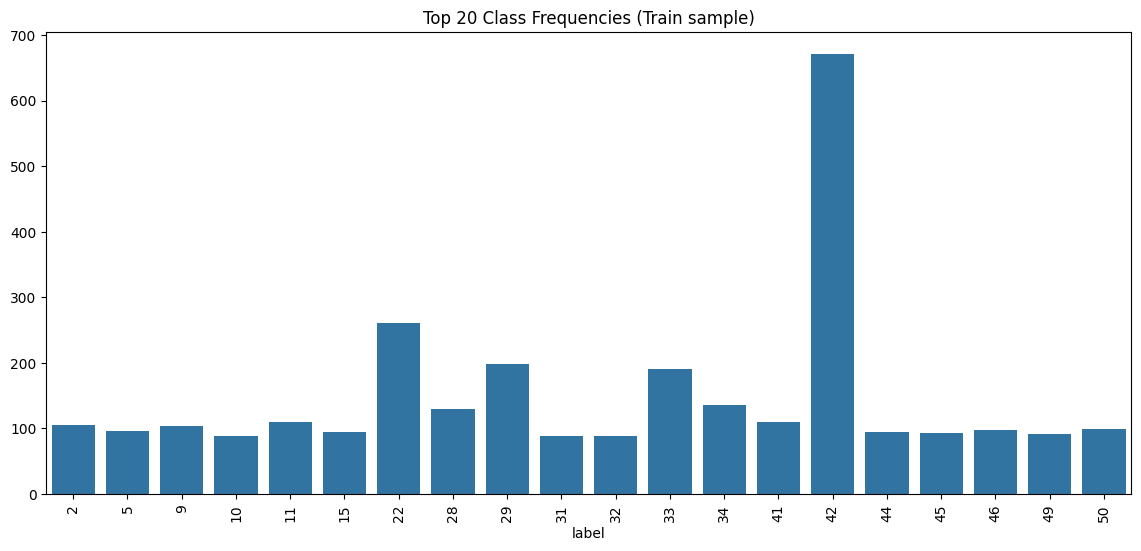

In [42]:
# !pip install -q datasets

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io

# ----------------------
# Load dataset (lazy)
# ----------------------
hf = load_dataset("pemujo/GLDv2_Top_51_Categories")

# Take only a sample for EDA
train_sample = hf["train"].shuffle(seed=42).select(range(5000))   # 5k rows
test_sample  = hf["test"].shuffle(seed=42).select(range(2000))    # 2k rows

# Convert sample to pandas
df_train = pd.DataFrame(train_sample)
df_test  = pd.DataFrame(test_sample)

# ----------------------
# Basic info
# ----------------------
print("Train sample size:", df_train.shape)
print("Test sample size:", df_test.shape)
print("Columns:", df_train.columns.tolist())

# Label distribution
label_counts = df_train['label'].value_counts()
print("\nNumber of classes (in sample):", df_train['label'].nunique())

plt.figure(figsize=(14,6))
sns.barplot(x=label_counts.index[:20], y=label_counts.values[:20])
plt.xticks(rotation=90)
plt.title("Top 20 Class Frequencies (Train sample)")
plt.show()


In [43]:
# df_test['category'].value_counts()

In [44]:

!pip install -q roboflow

In [45]:
# !pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="N79o2Kg5Jx1ItlvgpiNN")
project = rf.workspace("gp-j4r5m").project("augmented-iklfg")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


In [46]:
base_dir = "GLDv2_YOLO"
for split in ["train","test"]:
  os.makedirs(os.path.join(base_dir,"images",split),exist_ok=True)
  os.makedirs(os.path.join(base_dir,"labels",split),exist_ok=True)

In [47]:
def save_split(split_name):
  dataset=hf[split_name]
  for i,row in enumerate(dataset):
    img=row["image"].convert("RGB")

    img_name=f"{row['id']}.jpg"
    img_path=os.path.join(base_dir,"images",split_name,img_name)
    label_path=os.path.join(base_dir,"labels",split_name,f"{row['id']}.txt")

    img.save(img_path)

    class_id = row["label"]
    yolo_line = f"{class_id+84} 0.5 0.5 1.0 1.0\n"
    with open(label_path,"w") as f:
      f.write(yolo_line)

    if i%10000==0:
          print(f"{split_name}: Processed {i}/{len(dataset)}")

In [48]:
save_split("train")
save_split("test")
print("Done YOLO dataset ready in:",base_dir)

train: Processed 0/36463
train: Processed 10000/36463
train: Processed 20000/36463
train: Processed 30000/36463
test: Processed 0/9116
Done YOLO dataset ready in: GLDv2_YOLO


In [49]:
import os
import shutil
from sklearn.model_selection import train_test_split
import glob

gldv2_path = "/content/GLDv2_YOLO"
egypt_path = "/content/augmented-1"
output_path = "/content/merged_dataset"

for split in ["train", "val"]:
    os.makedirs(os.path.join(output_path, "images", split), exist_ok=True)
    os.makedirs(os.path.join(output_path, "labels", split), exist_ok=True)

def copy_dataset(src_img_dir, src_lbl_dir, dst_split):
    img_files = glob.glob(os.path.join(src_img_dir, "*.jpg")) + glob.glob(os.path.join(src_img_dir, "*.png"))
    for img_file in img_files:
        base = os.path.splitext(os.path.basename(img_file))[0]
        lbl_file = os.path.join(src_lbl_dir, base + ".txt")

        if not os.path.exists(lbl_file):
            continue

        shutil.copy(img_file, os.path.join(output_path, "images", dst_split, os.path.basename(img_file)))
        shutil.copy(lbl_file, os.path.join(output_path, "labels", dst_split, os.path.basename(lbl_file)))


copy_dataset(os.path.join(gldv2_path, "images", "train"),
             os.path.join(gldv2_path, "labels", "train"),
             "train")

copy_dataset(os.path.join(gldv2_path, "images", "test"),
             os.path.join(gldv2_path, "labels", "test"),
             "val")


copy_dataset(os.path.join(egypt_path, "train", "images"),
             os.path.join(egypt_path,"train", "labels"),
             "train")

copy_dataset(os.path.join(egypt_path, "val", "images"),
             os.path.join(egypt_path,"val", "labels"),
             "train")

copy_dataset(os.path.join(egypt_path, "test", "images"),
             os.path.join(egypt_path,"test", "labels"),
             "val")


print("Done Meraged", output_path)


Done Meraged /content/merged_dataset


In [50]:
import os
import glob

# number of images and classes in Egypt Dataset

egypt_path = "/content/augmented-1"

img_files = glob.glob(os.path.join(egypt_path,"**", "images",  "*.jpg"), recursive=True)
img_files += glob.glob(os.path.join(egypt_path,"**", "images",  "*.png"), recursive=True)
num_images = len(img_files)

class_ids = set()
label_files = glob.glob(os.path.join(egypt_path,"**", "labels",  "*.txt"), recursive=True)

for lf in label_files:
    with open(lf, "r") as f:
        for line in f:
            if line.strip():
                cid = int(line.split()[0])
                class_ids.add(cid)

num_classes = len(class_ids)

print(f"number of images {num_images}")
print(f"number of classes: {num_classes}")
# print(f"IDs: {sorted(class_ids)}")


number of images 13876
number of classes: 84


In [51]:
import os
import glob

# number of images and classes in Google Landmarks Dataset

gldv2_path = "/content/GLDv2_YOLO"

img_files = glob.glob(os.path.join(gldv2_path, "images", "**", "*.jpg"), recursive=True)
img_files += glob.glob(os.path.join(gldv2_path, "images", "**", "*.png"), recursive=True)
num_images = len(img_files)

class_ids = set()
label_files = glob.glob(os.path.join(gldv2_path, "labels", "**", "*.txt"), recursive=True)

for lf in label_files:
    with open(lf, "r") as f:
        for line in f:
            if line.strip():
                cid = int(line.split()[0])
                class_ids.add(cid)

num_classes = len(class_ids)

print(f"number of images {num_images}")
print(f"number of classes: {num_classes}")
# print(f"IDs: {sorted(class_ids)}")


number of images 45579
number of classes: 51


In [52]:
import os
import glob

# number of images and classes in All Dataset

dataset_path = "/content/merged_dataset"

img_files = glob.glob(os.path.join(dataset_path, "images", "**", "*.jpg"), recursive=True)
img_files += glob.glob(os.path.join(dataset_path, "images", "**", "*.png"), recursive=True)
num_images = len(img_files)

class_ids = set()
label_files = glob.glob(os.path.join(dataset_path, "labels", "**", "*.txt"), recursive=True)

for lf in label_files:
    with open(lf, "r") as f:
        for line in f:
            if line.strip():
                cid = int(line.split()[0])
                class_ids.add(cid)

num_classes = len(class_ids)

print(f"number of images {num_images}")
print(f"number of classes: {num_classes}")
# print(f"IDs: {sorted(class_ids)}")


number of images 58185
number of classes: 135


In [55]:
import os
import glob
import collections
import shutil
from sklearn.model_selection import train_test_split

In [60]:
def get_top_classes(dataset_path, top_n=20,egyORgoogle=0):

    if egyORgoogle == 0:
      label_files = glob.glob(os.path.join(dataset_path, "labels", "**", "*.txt"), recursive=True)

    if egyORgoogle == 1:
      label_files = glob.glob(os.path.join(dataset_path,"**", "labels", "*.txt"), recursive=True)

    class_counts = collections.Counter()
    for lf in label_files:
        with open(lf, "r") as f:
            for line in f:
                if line.strip():
                    cid = int(line.split()[0])
                    class_counts[cid] += 1
    return [cid for cid, _ in class_counts.most_common(top_n)]

In [61]:
def collect_class_subset(dataset_path, selected_classes,egyORgoogle=0):
    all_images, all_labels = [], []

    if egyORgoogle == 0:
      label_files = glob.glob(os.path.join(dataset_path, "labels", "**", "*.txt"), recursive=True)

    if egyORgoogle == 1:
      label_files = glob.glob(os.path.join(dataset_path,"**", "labels", "*.txt"), recursive=True)

    # label_files = glob.glob(os.path.join(dataset_path, "labels", "**", "*.txt"), recursive=True)

    for lf in label_files:
        with open(lf, "r") as f:
            lines = f.readlines()
            if not lines:
                continue
            cid = int(lines[0].split()[0])
            if cid in selected_classes:
                base = os.path.splitext(os.path.basename(lf))[0]

                if egyORgoogle == 0:
                  img_candidates = glob.glob(os.path.join(dataset_path, "images", "**", base + ".*"), recursive=True)

                if egyORgoogle == 1:
                  img_candidates = glob.glob(os.path.join(dataset_path, "**", "images", base + ".*"), recursive=True)

                # img_candidates = glob.glob(os.path.join(dataset_path, "images", "**", base + ".*"), recursive=True)
                if img_candidates:
                    all_images.append(img_candidates[0])
                    all_labels.append(lf)
    return all_images, all_labels

In [62]:
def merge_datasets(egypt_path, gldv2_path, output_path, top_n=20):
    # 1) احسب أعلى 20 من كل واحدة
    top20_egypt = get_top_classes(egypt_path, top_n=top_n,egyORgoogle=1)
    top20_gldv2 = get_top_classes(gldv2_path, top_n=top_n)
    print("📌 Top 20 Egypt:", top20_egypt)
    print("📌 Top 20 GLDv2:", top20_gldv2)

    # 2) جمع الصور والليبلز
    imgs_egypt, lbls_egypt = collect_class_subset(egypt_path, top20_egypt,egyORgoogle=1)
    imgs_gld, lbls_gld = collect_class_subset(gldv2_path, top20_gldv2)

    all_images = imgs_egypt + imgs_gld
    all_labels = lbls_egypt + lbls_gld

    print(f"📊 Collected {len(all_images)} images total")

    # 3) Split train/test
    train_imgs, test_imgs, train_lbls, test_lbls = train_test_split(
        all_images, all_labels, test_size=0.2, random_state=42,shuffle=True
    )

    # 4) أنشئ المجلدات
    for split in ["train", "test"]:
        os.makedirs(os.path.join(output_path, "images", split), exist_ok=True)
        os.makedirs(os.path.join(output_path, "labels", split), exist_ok=True)

    # 5) نسخ train
    for img, lbl in zip(train_imgs, train_lbls):
        shutil.copy(img, os.path.join(output_path, "images", "train", os.path.basename(img)))
        shutil.copy(lbl, os.path.join(output_path, "labels", "train", os.path.basename(lbl)))

    # 6) نسخ test
    for img, lbl in zip(test_imgs, test_lbls):
        shutil.copy(img, os.path.join(output_path, "images", "test", os.path.basename(img)))
        shutil.copy(lbl, os.path.join(output_path, "labels", "test", os.path.basename(lbl)))

    print(f"✅ Done! {len(train_imgs)} train + {len(test_imgs)} test saved in {output_path}")


In [63]:
# ---------- تنفيذ ----------
egypt_path = "/content/augmented-1"
gldv2_path = "/content/GLDv2_YOLO"
output_path = "/content/Merged_Top20_YOLO"

merge_datasets(egypt_path, gldv2_path, output_path, top_n=20)

📌 Top 20 Egypt: [19, 53, 24, 36, 5, 44, 41, 2, 82, 72, 34, 32, 0, 80, 62, 70, 56, 27, 69, 1]
📌 Top 20 GLDv2: [126, 106, 113, 117, 112, 118, 125, 122, 134, 86, 95, 129, 130, 103, 99, 128, 89, 102, 93, 110]
📊 Collected 35410 images total
✅ Done! 28328 train + 7082 test saved in /content/Merged_Top20_YOLO


In [64]:
import os
import glob

# number of images and classes in Merged_Top20_YOLO Dataset

dataset_path = "/content/Merged_Top20_YOLO"

img_files = glob.glob(os.path.join(dataset_path, "images", "**", "*.jpg"), recursive=True)
img_files += glob.glob(os.path.join(dataset_path, "images", "**", "*.png"), recursive=True)
num_images = len(img_files)

class_ids = set()
label_files = glob.glob(os.path.join(dataset_path, "labels", "**", "*.txt"), recursive=True)

for lf in label_files:
    with open(lf, "r") as f:
        for line in f:
            if line.strip():
                cid = int(line.split()[0])
                class_ids.add(cid)

num_classes = len(class_ids)

print(f"number of images {num_images}")
print(f"number of classes: {num_classes}")
# print(f"IDs: {sorted(class_ids)}")


number of images 35410
number of classes: 40


Image ID     : 305c238a4b31c2e9
Landmark ID  : 20409
Category     : Noraduz_Cemetery
Label (class): 29


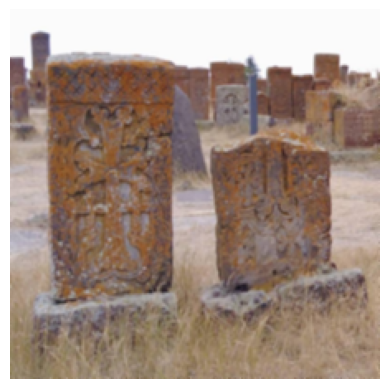

In [ ]:
import random
import matplotlib.pyplot as plt

# Pick a random sample
idx = random.randint(0, len(df_train)-1)
row = df_train.iloc[idx]

# Show metadata
print(f"Image ID     : {row['id']}")
print(f"Landmark ID  : {row['landmark_id']}")
print(f"Category     : {row['category']}")
print(f"Label (class): {row['label']}")

# Show image
plt.imshow(row['image'])
plt.axis("off")
plt.show()



[1]
Image ID     : 6b475690d395c0ab
Landmark ID  : 41648
Category     : Akkerman_fortress
Label (class): 24


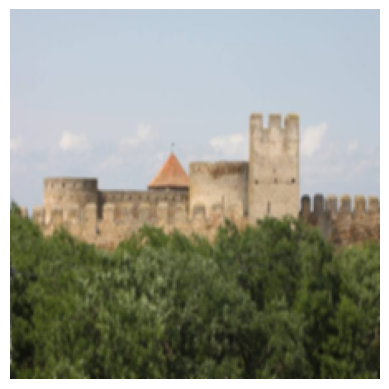


[2]
Image ID     : e1ebdc3e39fb3c4e
Landmark ID  : 36748
Category     : Kecharis
Label (class): 5


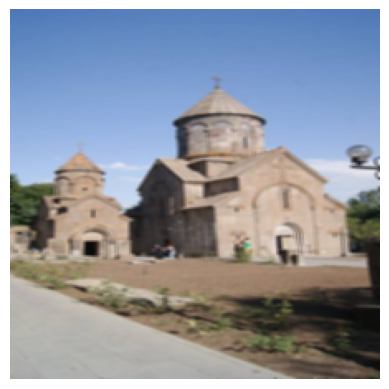


[3]
Image ID     : a3c12b43f36bce45
Landmark ID  : 139894
Category     : Pe%C5%A1ter
Label (class): 50


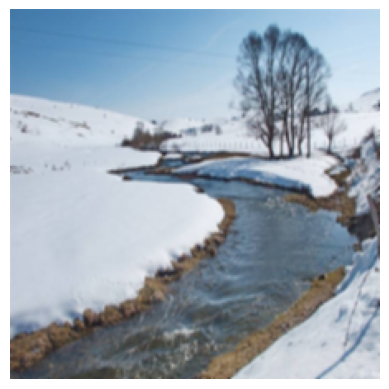


[4]
Image ID     : bbaec97499f2c971
Landmark ID  : 194914
Category     : Nieuwe_Waterweg
Label (class): 41


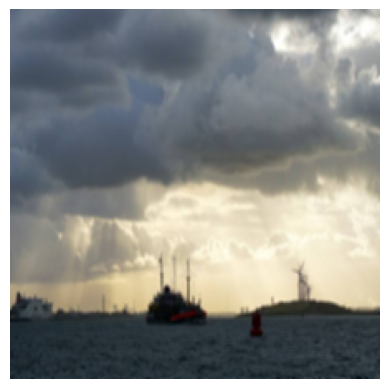


[5]
Image ID     : 6cf9e3a922e2fcbf
Landmark ID  : 194914
Category     : Nieuwe_Waterweg
Label (class): 41


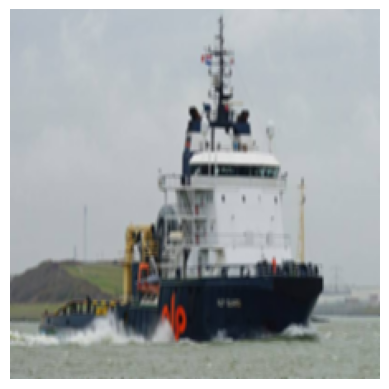


[6]
Image ID     : 814b4129922f52d2
Landmark ID  : 120734
Category     : Mathura_Museum
Label (class): 18


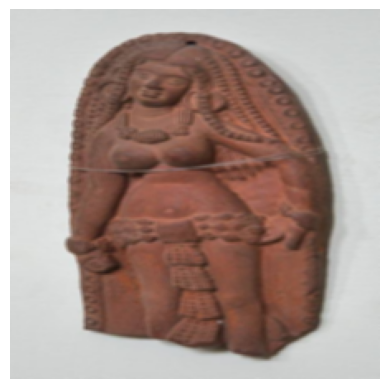


[7]
Image ID     : 79452c2eda70a3be
Landmark ID  : 177870
Category     : Lviv
Label (class): 34


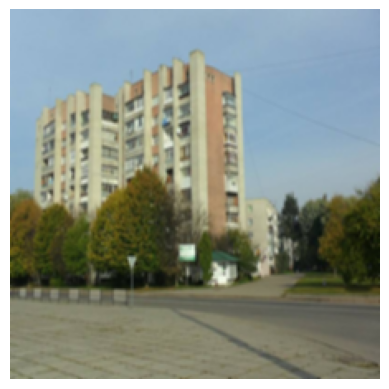


[8]
Image ID     : 4bcb8569c4e9c867
Landmark ID  : 139894
Category     : Pe%C5%A1ter
Label (class): 50


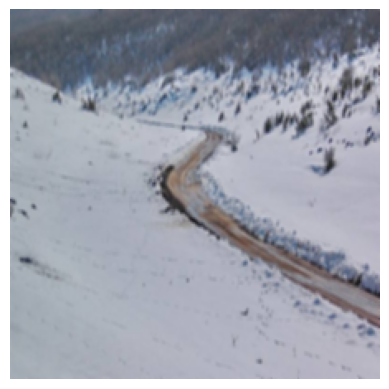


[9]
Image ID     : 50940f1a33787a65
Landmark ID  : 138982
Category     : Media_contributed_by_the_ETH-Bibliothek
Label (class): 42


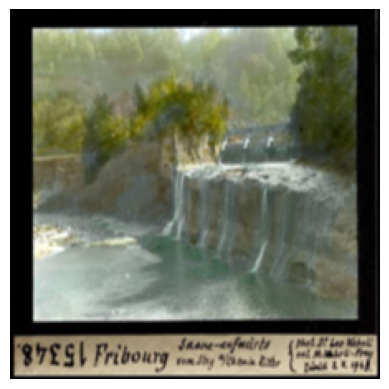


[10]
Image ID     : 39c8552d34c72e3c
Landmark ID  : 168098
Category     : Golden_Gate_Bridge
Label (class): 19


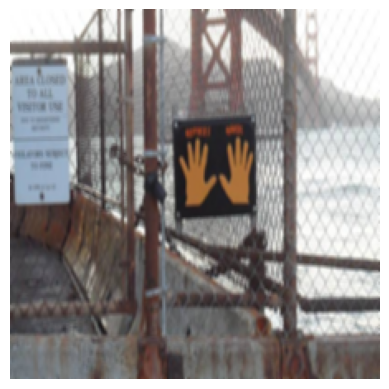


[11]
Image ID     : d91ca7f280c2b878
Landmark ID  : 27190
Category     : Perperikon
Label (class): 27


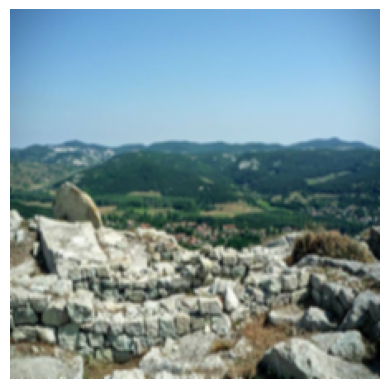


[12]
Image ID     : 1a0604f2f5bfa41a
Landmark ID  : 190822
Category     : Faisal_Mosque
Label (class): 43


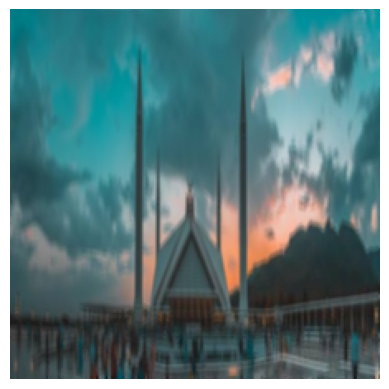


[13]
Image ID     : 026afdc670937e3b
Landmark ID  : 27
Category     : Isa_Khan_Niyazi's_tomb
Label (class): 16


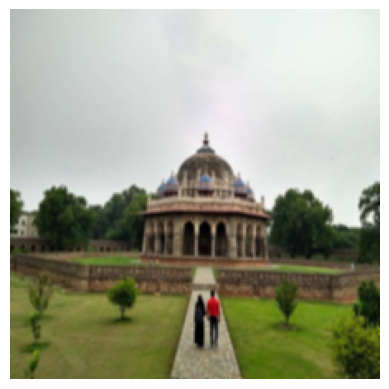


[14]
Image ID     : 96f2baa23a72a725
Landmark ID  : 10419
Category     : Qutb_Minar_and_its_monuments,_Delhi
Label (class): 26


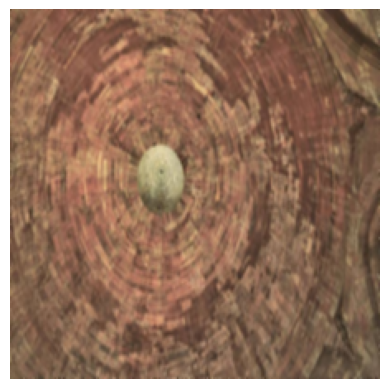


[15]
Image ID     : 333970ee83a082e3
Landmark ID  : 126637
Category     : Corktown,_Toronto
Label (class): 22


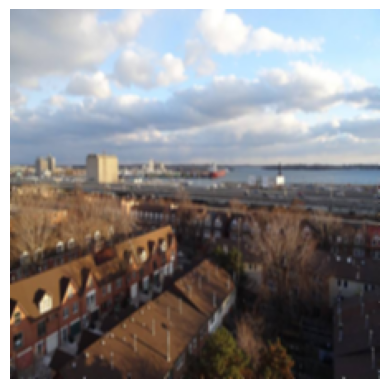


[16]
Image ID     : 071931ef6077ac2f
Landmark ID  : 9070
Category     : Feroz_Shah_Kotla
Label (class): 45


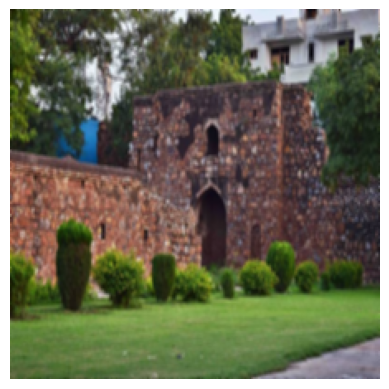


[17]
Image ID     : d82fda1d2a41126c
Landmark ID  : 85633
Category     : %C3%87ufut_Qale
Label (class): 0


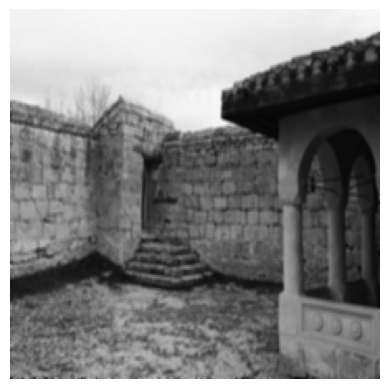


[18]
Image ID     : 34ae67abde269c09
Landmark ID  : 64792
Category     : Victoria_Memorial,_Kolkata
Label (class): 14


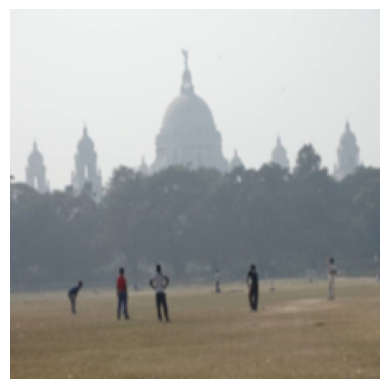


[19]
Image ID     : 3771c8c492dc622b
Landmark ID  : 10419
Category     : Qutb_Minar_and_its_monuments,_Delhi
Label (class): 26


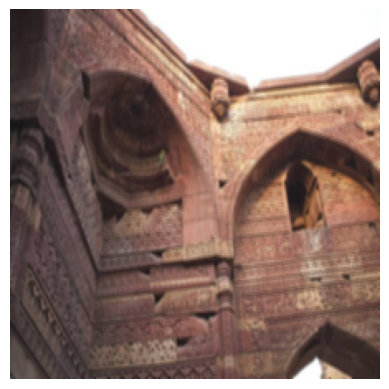


[20]
Image ID     : 8367eef14c0f46ac
Landmark ID  : 46705
Category     : Grand_Canyon
Label (class): 46


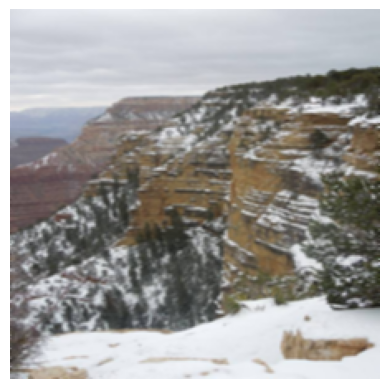

In [ ]:
import matplotlib.pyplot as plt

# Display first 20 samples
for i in range(20):
    row = df_train.iloc[i]

    print(f"\n[{i+1}]")
    print(f"Image ID     : {row['id']}")
    print(f"Landmark ID  : {row['landmark_id']}")
    print(f"Category     : {row['category']}")
    print(f"Label (class): {row['label']}")

    # Show image
    plt.imshow(row['image'])
    plt.axis("off")
    plt.show()


In [ ]:
sorted_categories = sorted(df_train['category'].unique())
for i, cat in enumerate(sorted_categories, 1):
    print(f"{i}. {cat}")


1. %C3%87ufut_Qale
2. Akbar's_Tomb
3. Akkerman_fortress
4. Catedral_San_Sebasti%C3%A1n,_Cochabamba
5. Corktown,_Toronto
6. Douthat_State_Park
7. Edinburgh_Castle
8. Eiffel_Tower
9. Episcopal_Diocese_of_Southwest_Florida
10. Faisal_Mosque
11. Feroz_Shah_Kotla
12. Genoese_fortress_(Sudak)
13. Golden_Gate_Bridge
14. Grand_Canyon
15. Grote_of_Onze-Lieve-Vrouwekerk_(Breda)
16. Haghpat
17. Haleakal%C4%81_National_Park
18. Harichavank
19. Hayravank_monastery
20. Isa_Khan_Niyazi's_tomb
21. Itmad-Ud-Daulah's_Tomb
22. Jurassic_Coast
23. Kecharis
24. Khotyn_Fortress
25. Lake_Como
26. Ljubljana_Castle
27. Lviv
28. Madrid_R%C3%ADo
29. Masada
30. Mathura_Museum
31. Matka_Canyon
32. Media_contributed_by_the_ETH-Bibliothek
33. Museum_of_Folk_Architecture_and_Ethnography_in_Pyrohiv
34. Niagara_Falls
35. Nieuwe_Waterweg
36. Noraduz_Cemetery
37. Nyhavn
38. Ogrodzieniec_Castle
39. Pakistan_Monument_Islamabad
40. Pe%C5%A1ter
41. Perperikon
42. Purana_Qila
43. Qutb_Minar_and_its_monuments,_Delhi
44. Saint_H